# Notebook 1 — Data Exploration

Explores the prescription-OCR dataset **before** any modelling:
label cleaning, field coverage, medication statistics, image-size analysis,
tokeniser-level length profiling, format validation, and split preview.


## 1. Setup


In [1]:
%matplotlib inline
import os, sys, json, random, re
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

sys.path.insert(0, os.path.abspath('..'))
ROOT = os.path.abspath('..')
IMAGES_DIR = os.path.join(ROOT, 'data', 'raw', 'images')
ANNOTATIONS_DIR = os.path.join(ROOT, 'data', 'raw', 'annotations')

random.seed(42)
np.random.seed(42)

print(f'Project root : {ROOT}')
print(f'Images dir   : {IMAGES_DIR}  (exists={os.path.isdir(IMAGES_DIR)})')
print(f'Annotations  : {ANNOTATIONS_DIR}  (exists={os.path.isdir(ANNOTATIONS_DIR)})')


Project root : /home/lokmane/Desktop/Medical_Prescription_OCR
Images dir   : /home/lokmane/Desktop/Medical_Prescription_OCR/data/raw/images  (exists=True)
Annotations  : /home/lokmane/Desktop/Medical_Prescription_OCR/data/raw/annotations  (exists=True)


## 2. Load All Samples


In [2]:
def list_files(folder, ext):
    return sorted(f for f in os.listdir(folder) if f.lower().endswith(ext))

samples, missing = [], []
image_files = list_files(IMAGES_DIR, '.png')
print(f'PNG files found: {len(image_files)}')

for fname in image_files:
    stem = os.path.splitext(fname)[0]
    ann_path = os.path.join(ANNOTATIONS_DIR, stem + '.json')
    if not os.path.isfile(ann_path):
        missing.append(fname)
        continue
    with open(ann_path, encoding='utf-8') as f:
        ann = json.load(f)
    gt = ann.get('ground_truth', ann.get('text', ''))
    samples.append({
        'id': stem,
        'image_path': os.path.join(IMAGES_DIR, fname),
        'annotation_path': ann_path,
        'text': gt,
    })

print(f'Valid pairs   : {len(samples)}')
if missing:
    print(f'Missing annot.: {len(missing)} — first 5: {missing[:5]}')


PNG files found: 1000
Valid pairs   : 1000


## 3. Label Cleaning & Field Extraction


In [3]:
KNOWN_FIELDS = [
    'doctor_name', 'clinic_name', 'clinic_address',
    'patient_name', 'patient_age', 'date',
    'medications', 'signature',
]

def strip_ocr_tokens(text):
    return re.sub(r'\s+', ' ', text.replace('<s_ocr>', '').replace('</s>', '')).strip()

def extract_field(text, field):
    others = '|'.join(f for f in KNOWN_FIELDS if f != field)
    m = re.search(rf'{field}:\s*(.+?)(?=\s+(?:{others}):|$)', text, re.I | re.DOTALL)
    return m.group(1).strip() if m else ''

def extract_medications(text):
    med_block = extract_field(text, 'medications')
    if not med_block:
        return []
    parts = re.split(r'\s*-\s*', med_block)
    meds = []
    i = 0
    while i < len(parts):
        name = parts[i].strip()
        if not name:
            i += 1
            continue
        freq = parts[i + 1].strip() if i + 1 < len(parts) else ''
        meds.append({'drug': name, 'frequency': freq})
        i += 2
    return meds

cleaned_texts = [strip_ocr_tokens(s['text']) for s in samples]
print(f'Cleaned {len(cleaned_texts)} labels')
print(f'Example (first 120 chars): {cleaned_texts[0][:120]}...')


Cleaned 1000 labels
Example (first 120 chars): doctor_name: Dr. F. Gomez clinic_name: Meadowview Health clinic_address: 45 Oak Ave. patient_name: Michael Brown patient...


## 4. Field Coverage Analysis

Check which fields are present/missing across the whole dataset — useful for
understanding annotation quality and deciding which fields to parse.


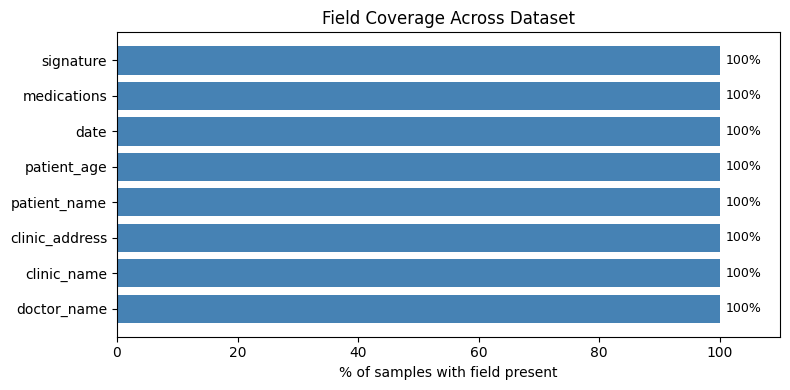

In [4]:
field_presence = {f: 0 for f in KNOWN_FIELDS}
for text in cleaned_texts:
    for f in KNOWN_FIELDS:
        if extract_field(text, f):
            field_presence[f] += 1

fig, ax = plt.subplots(figsize=(8, 4))
fields = list(field_presence.keys())
counts = [field_presence[f] for f in fields]
pcts = [100 * c / len(cleaned_texts) for c in counts]
bars = ax.barh(fields, pcts, color='steelblue')
ax.set_xlabel('% of samples with field present')
ax.set_title('Field Coverage Across Dataset')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}%', va='center', fontsize=9)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()


## 5. Medication Statistics


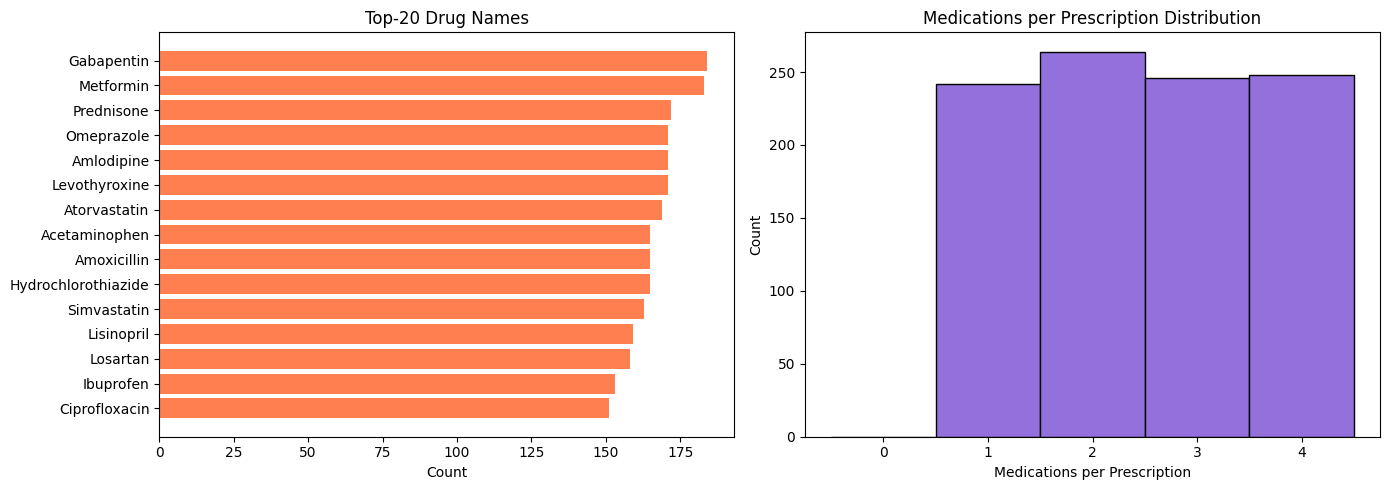

Unique drug names: 15
Avg meds/prescription: 2.5 (std 1.1)


In [5]:
all_meds = []
meds_per_rx = []
for text in cleaned_texts:
    m = extract_medications(text)
    meds_per_rx.append(len(m))
    for entry in m:
        drug = re.split(r'\d', entry['drug'])[0].strip()
        if drug:
            all_meds.append(drug)

med_counts = Counter(all_meds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-20 drug names
top20 = med_counts.most_common(20)
axes[0].barh([d for d, _ in top20], [c for _, c in top20], color='coral')
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')
axes[0].set_title('Top-20 Drug Names')

# Meds per prescription
axes[1].hist(meds_per_rx, bins=range(0, max(meds_per_rx) + 2),
             edgecolor='black', align='left', color='mediumpurple')
axes[1].set_xlabel('Medications per Prescription')
axes[1].set_ylabel('Count')
axes[1].set_title('Medications per Prescription Distribution')

plt.tight_layout()
plt.show()
print(f'Unique drug names: {len(med_counts)}')
print(f'Avg meds/prescription: {np.mean(meds_per_rx):.1f} (std {np.std(meds_per_rx):.1f})')


## 6. Patient Age Distribution


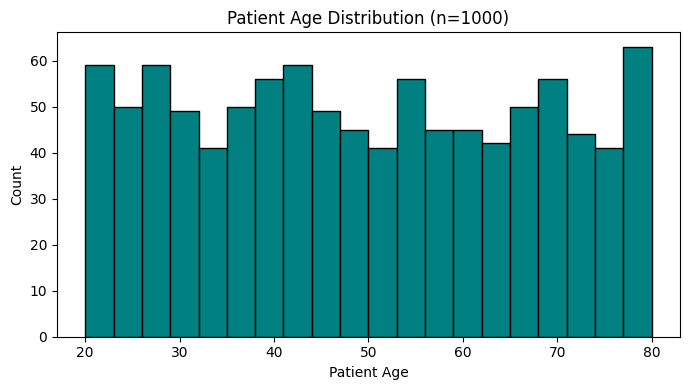

Age range: 20–80, median: 48


In [6]:
ages = []
for text in cleaned_texts:
    age_str = extract_field(text, 'patient_age')
    digits = re.findall(r'\d+', age_str)
    if digits:
        ages.append(int(digits[0]))

plt.figure(figsize=(7, 4))
plt.hist(ages, bins=20, edgecolor='black', color='teal')
plt.xlabel('Patient Age')
plt.ylabel('Count')
plt.title(f'Patient Age Distribution (n={len(ages)})')
plt.tight_layout()
plt.show()
print(f'Age range: {min(ages)}–{max(ages)}, median: {int(np.median(ages))}')


## 7. Image Dimension Analysis


Reading dimensions: 100%|██████████| 1000/1000 [00:00<00:00, 1903.81it/s]


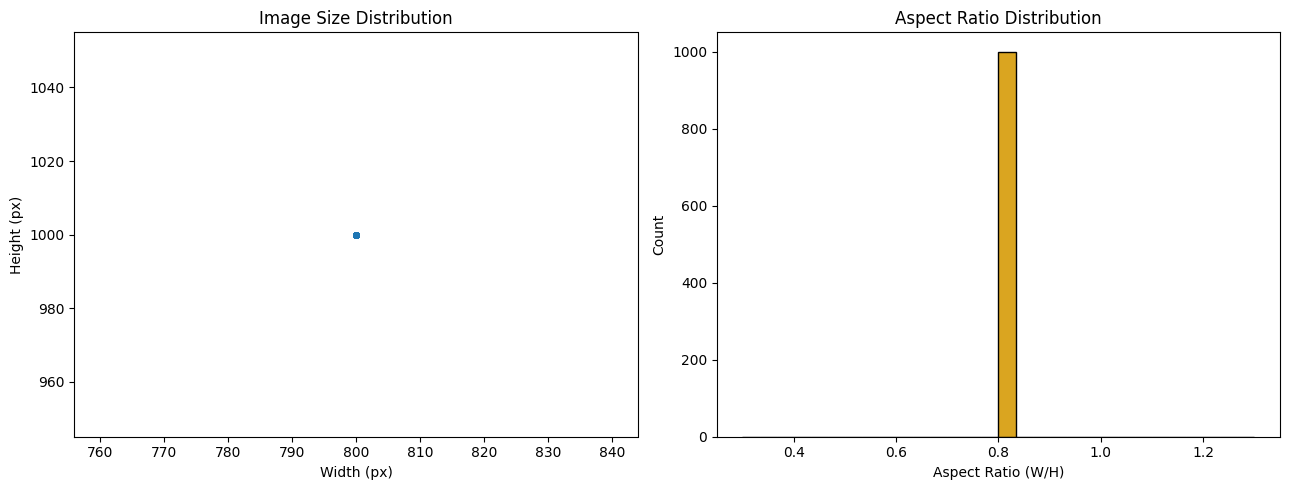

Width  — min: 800, max: 800, mean: 800, std: 0
Height — min: 1000, max: 1000, mean: 1000, std: 0


In [7]:
widths, heights = [], []
for s in tqdm(samples, desc='Reading dimensions'):
    with Image.open(s['image_path']) as img:
        w, h = img.size
    widths.append(w)
    heights.append(h)

widths_np, heights_np = np.array(widths), np.array(heights)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(widths_np, heights_np, alpha=0.4, s=15)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Image Size Distribution')

aspects = widths_np / heights_np
axes[1].hist(aspects, bins=30, edgecolor='black', color='goldenrod')
axes[1].set_xlabel('Aspect Ratio (W/H)')
axes[1].set_ylabel('Count')
axes[1].set_title('Aspect Ratio Distribution')

plt.tight_layout()
plt.show()

print(f'Width  — min: {widths_np.min()}, max: {widths_np.max()}, '
      f'mean: {widths_np.mean():.0f}, std: {widths_np.std():.0f}')
print(f'Height — min: {heights_np.min()}, max: {heights_np.max()}, '
      f'mean: {heights_np.mean():.0f}, std: {heights_np.std():.0f}')


## 8. Sample Images with Ground Truth


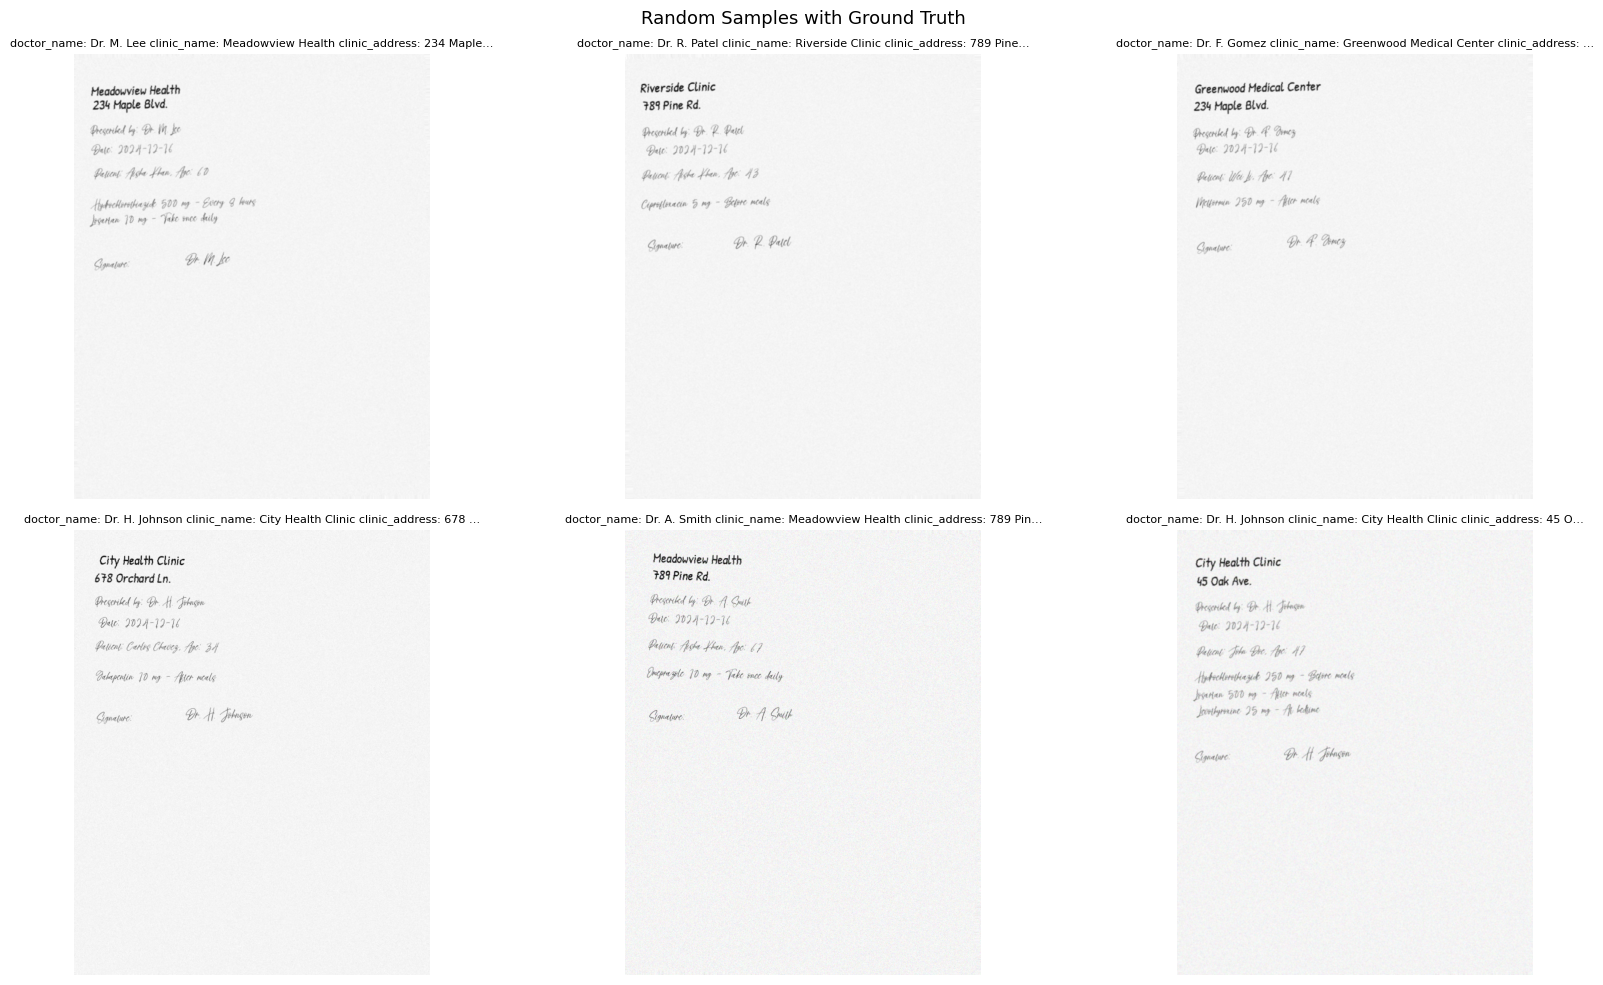

In [8]:
chosen = random.sample(samples, min(6, len(samples)))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, s in zip(axes.flatten(), chosen):
    img = Image.open(s['image_path']).convert('RGB')
    ax.imshow(np.array(img))
    clean = strip_ocr_tokens(s['text'])
    ax.set_title(clean[:80] + '…', fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('Random Samples with Ground Truth', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Text Length Analysis (Characters + TrOCR Tokens)

We check both raw character length and **tokeniser** length so we can
confirm that `max_length=256` covers the vast majority of labels.


/home/lokmane/Desktop/Medical_Prescription_OCR/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


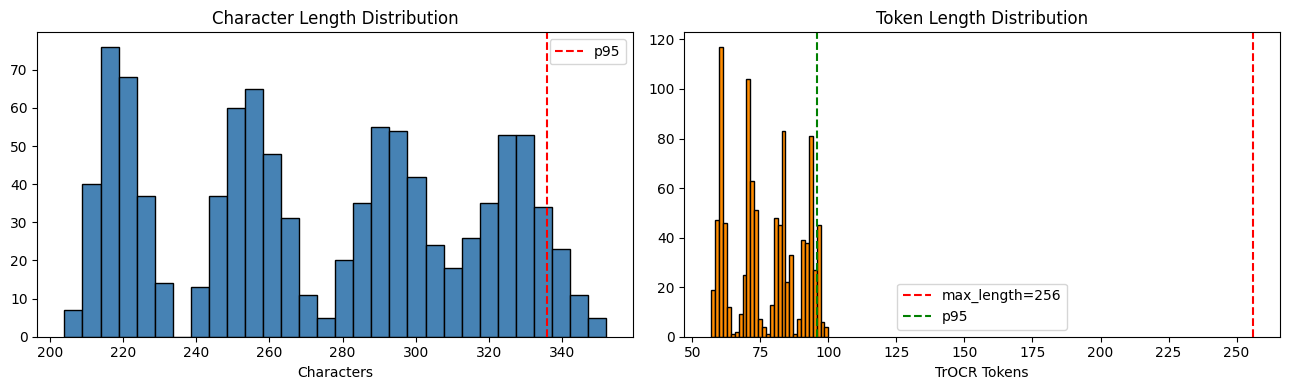

Char length  — mean: 274, p95: 336, max: 352
Token length — mean: 77, p95: 96, max: 100
Samples truncated at max_length=256: 0/1000 (0.0%)


In [9]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-small-handwritten')

char_lens = [len(t) for t in cleaned_texts]
tok_lens = [len(processor.tokenizer(t, add_special_tokens=False).input_ids)
            for t in cleaned_texts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(char_lens, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(np.percentile(char_lens, 95), color='red', ls='--', label='p95')
axes[0].set_xlabel('Characters')
axes[0].set_title('Character Length Distribution')
axes[0].legend()

axes[1].hist(tok_lens, bins=30, edgecolor='black', color='darkorange')
axes[1].axvline(256, color='red', ls='--', label='max_length=256')
axes[1].axvline(np.percentile(tok_lens, 95), color='green', ls='--', label='p95')
axes[1].set_xlabel('TrOCR Tokens')
axes[1].set_title('Token Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = sum(1 for t in tok_lens if t > 256)
print(f'Char length  — mean: {np.mean(char_lens):.0f}, p95: {np.percentile(char_lens, 95):.0f}, max: {max(char_lens)}')
print(f'Token length — mean: {np.mean(tok_lens):.0f}, p95: {np.percentile(tok_lens, 95):.0f}, max: {max(tok_lens)}')
print(f'Samples truncated at max_length=256: {truncated}/{len(tok_lens)} ({100*truncated/len(tok_lens):.1f}%)')


## 10. Label Format Validation


In [10]:
valid, issues = 0, []
for s in tqdm(samples, desc='Validating'):
    ok = True
    if not os.path.exists(s['image_path']):
        issues.append((s['id'], 'missing_image'))
        ok = False
    with open(s['annotation_path'], encoding='utf-8') as f:
        ann = json.load(f)
    gt = ann.get('ground_truth', '')
    if not gt:
        issues.append((s['id'], 'empty_ground_truth'))
        ok = False
    if '<s_ocr>' not in gt:
        issues.append((s['id'], 'no_s_ocr_token'))
    if ok:
        valid += 1

print(f'Valid: {valid}/{len(samples)}')
if issues:
    print(f'Issues ({len(issues)}):')
    for sid, reason in issues[:10]:
        print(f'  {sid}: {reason}')


Validating: 100%|██████████| 1000/1000 [00:00<00:00, 32018.81it/s]

Valid: 1000/1000
